# 4.1 — Elemental Encoder Comparison

This notebook trains CrabNet with **8 different elemental embeddings**
(without Pettifor `extend_features`) to evaluate encoder sensitivity.

It includes the 7 built-in CrabNet encoders **plus** the Pettifor
similarity matrix registered as a custom `elem_prop`.

> **Important**: CrabNet v2.0.8 has a bug where `elem_prop` is not
> propagated to the `Embedder`, silently defaulting all models to
> `mat2vec`. A monkey-patch is applied below to fix this.

Encoders tested:
`jarvis`, `magpie`, `mat2vec`, `oliynyk`, `onehot`, `ptable`, `random_200`, `pettifor`

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Patch SWA for PyTorch >= 2.x compatibility ---
from crabnet.utils.optim import SWA  # type: ignore
_original_swa_init = SWA.__init__
def _patched_swa_init(self, *args, **kwargs):
    _original_swa_init(self, *args, **kwargs)
    if not hasattr(self, '_optimizer_step_pre_hooks'):
        self._optimizer_step_pre_hooks = {}
    if not hasattr(self, '_optimizer_step_post_hooks'):
        self._optimizer_step_post_hooks = {}
SWA.__init__ = _patched_swa_init
# ------------------------------------------------

# --- Patch CrabNet elem_prop propagation bug ---
import chalcogenide_perovskite_screening.modeling.CrabNet.patches as _patches
importlib.reload(_patches)                    # pick up code changes without kernel restart
_patches.patch_crabnet_elem_prop()
# ------------------------------------------------

from crabnet.crabnet_ import CrabNet          # type: ignore
from crabnet.utils.data import groupby_formula # type: ignore

from chalcogenide_perovskite_screening.config import TRAINED_MODELS, FIGURES_DIR
from chalcogenide_perovskite_screening.modeling.CrabNet.utils import (
    DEVICE,
    get_raw_data,
    get_pettifor_features,
    register_pettifor_elem_prop,
    test_r2_score,
)

print(f'Device: {DEVICE}')

2026-02-25 20:56:16.287 | INFO     | chalcogenide_perovskite_screening.config:<module>:11 - PROJ_ROOT path is: /home/dagar/TF-ChPVK-PV


2026-02-25 20:56:16.505 | INFO     | chalcogenide_perovskite_screening.modeling.CrabNet.utils:<module>:20 - CrabNet device: cuda


[patch] CrabNet elem_prop propagation fixed.
Device: cuda


## Data Preparation

Load, clean, group, and split exactly as in notebook 4. Pettifor columns
are computed (to get the same train/val/test split) but then **dropped**
before training.

In [2]:
df = get_raw_data()
df.rename(columns={'bandgap': 'target', 'reduced_formulas': 'formula'}, inplace=True)

df_grouped = groupby_formula(df, how='median')

for formula in df_grouped['formula']:
    df_grouped.loc[df_grouped['formula'] == formula, 'source'] = (
        df.loc[df['formula'] == formula, 'source'].values[0]
    )
df_grouped_no_src = df_grouped.drop(columns=['source'])

train_df, val_df, test_df, feature_names = get_pettifor_features(
    df_grouped_no_src, original_df=df, train=True
)

# Register Pettifor as a CrabNet elem_prop (so it can be used like mat2vec, etc.)
register_pettifor_elem_prop()

# Drop Pettifor columns — encoder comparison uses only the elemental embedding
train_base = train_df.drop(columns=feature_names)
val_base   = val_df.drop(columns=feature_names)
test_base  = test_df.drop(columns=feature_names)

print(f'Train: {len(train_base)}  |  Val: {len(val_base)}  |  Test: {len(test_base)}')

The data comes from the following sources:
74.16 % from halide perovskites,
0.0261 % from chalcogenides perovskites,
25.82 % from chalcogenide semiconductors


2026-02-25 20:56:37.669 | INFO     | chalcogenide_perovskite_screening.modeling.CrabNet.utils:register_pettifor_elem_prop:395 - Pettifor elem_prop already registered at /home/dagar/anaconda3/envs/py311-chpvk/lib/python3.11/site-packages/crabnet/data/element_properties/pettifor.csv
Train: 2902  |  Val: 363  |  Test: 363


## Train & Evaluate Each Encoder


Encoder: magpie

Model architecture: out_dims, d_model, N, heads
3, 512, 3, 4
Running on compute device: cuda:0


Model size: 11896070 parameters



Generating EDM:   0%|          | 0/2902 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 2902/2902 [00:00<00:00, 125660.68formulae/s]

skipping composition OrderedDict([('H', 14.0), ('C', 5.0), ('N', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 595.0), ('I', 300.0), ('N', 198.0), ('Pb', 100.0), ('C', 99.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 271.0), ('C', 109.0), ('N', 20.0), ('F', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 13.0), ('C', 2.0), ('N', 2.0), ('P', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 30.0), ('I', 13.0), ('C', 7.0), ('N', 4.0), ('Pb', 4.0), ('B', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 558.0), ('I', 300.0), ('Pb', 100.0), ('C', 93.0), ('N', 93.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 24.0), ('I', 13.0), ('C', 4.0), ('N', 4.0), ('Pb', 4.0), ('Ac', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('I', 9.0), ('Ga', 1.0), ('In', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 5.0), ('I', 3.0), ('N', 2.0), ('C', 1.0), ('Sn

Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 252744.41formulae/s]

skipping composition OrderedDict([('H', 585.0), ('I', 300.0), ('N', 194.0), ('Pb', 100.0), ('C', 97.0), ('S', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 145.0), ('I', 75.0), ('N', 48.0), ('Pb', 25.0), ('C', 24.0), ('S', 1.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
stepping every 120 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.455 val mae: 0.456


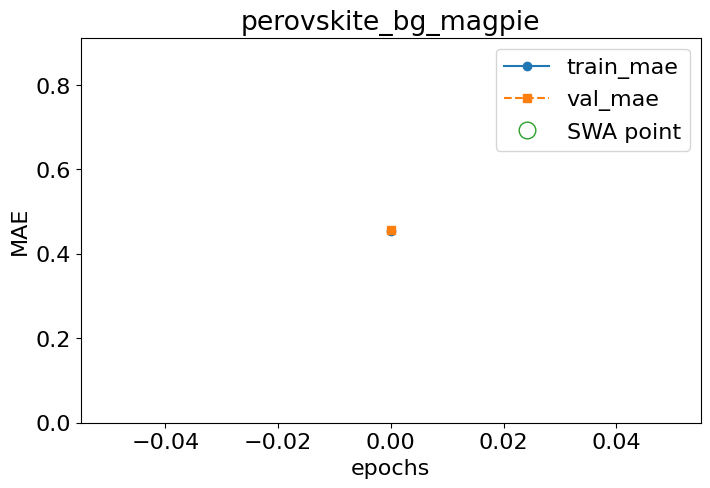

Epoch: 19/300 --- train mae: 0.312 val mae: 0.323


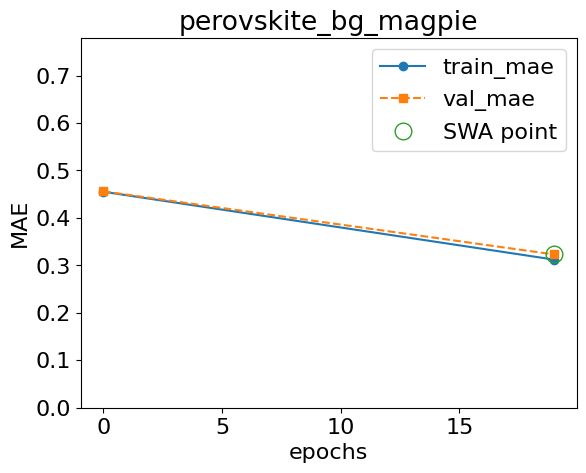

Epoch: 39/300 --- train mae: 0.273 val mae: 0.303


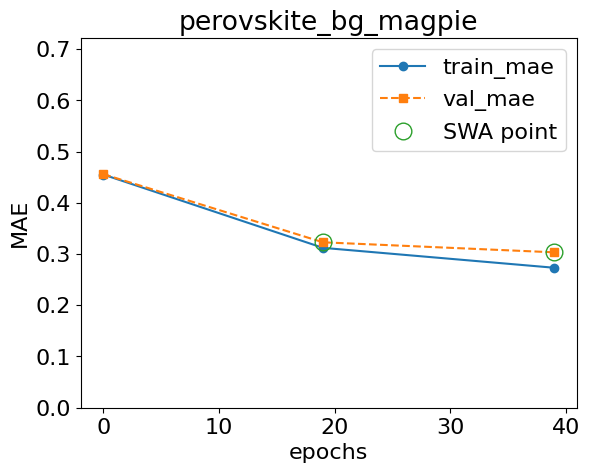

Epoch: 59/300 --- train mae: 0.248 val mae: 0.3


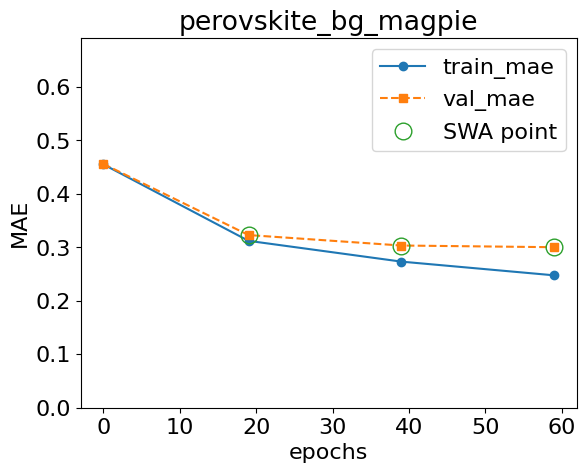

Epoch: 79/300 --- train mae: 0.232 val mae: 0.296


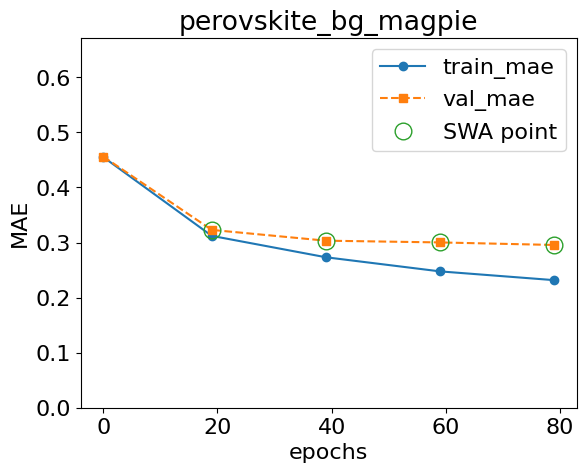

Epoch: 99/300 --- train mae: 0.212 val mae: 0.284


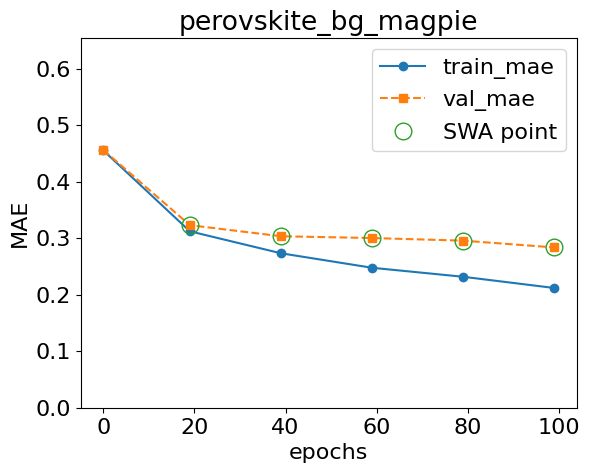

Epoch: 119/300 --- train mae: 0.2 val mae: 0.283


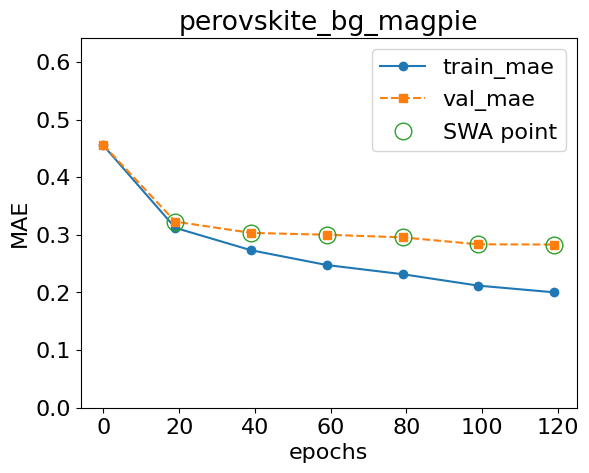

Epoch 139 failed to improve.
Discarded: 1/3 weight updates


Epoch: 139/300 --- train mae: 0.189 val mae: 0.289


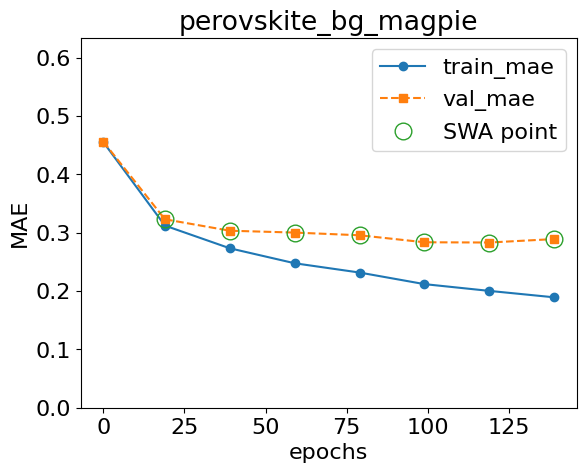

Epoch 159 failed to improve.
Discarded: 2/3 weight updates


Epoch: 159/300 --- train mae: 0.175 val mae: 0.289


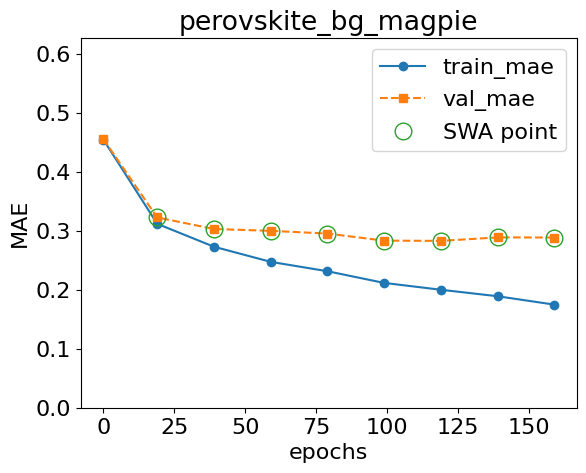

Epoch 179 failed to improve.
Discarded: 3/3 weight updates


Epoch: 179/300 --- train mae: 0.171 val mae: 0.286


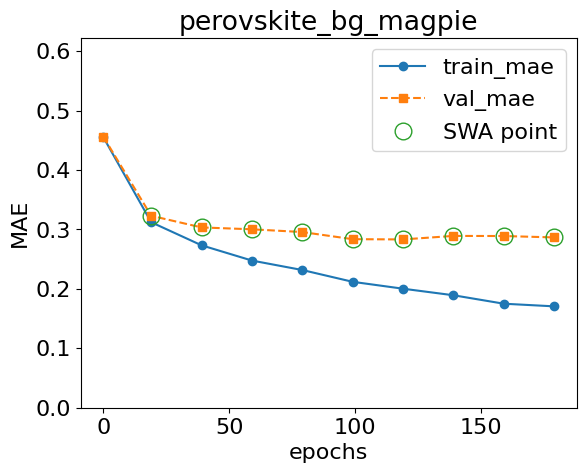

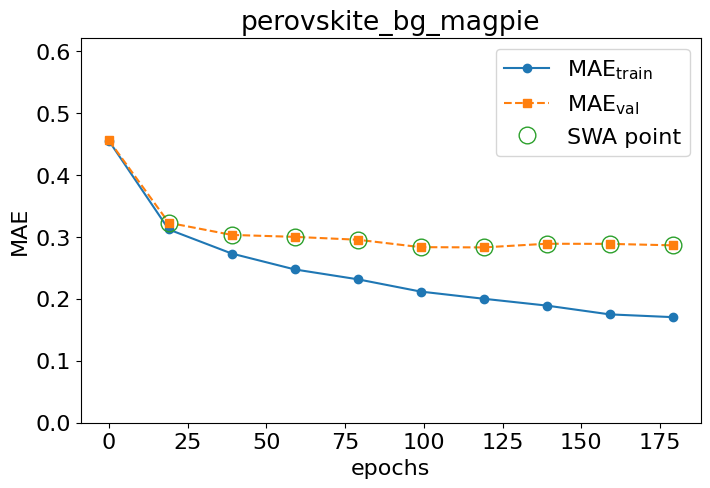

Discarded: 3/3weight updates, early-stopping now
Saving network (perovskite_bg_magpie) to models/trained_models/perovskite_bg_magpie.pth


Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 190316.54formulae/s]

skipping composition OrderedDict([('H', 115.0), ('I', 60.0), ('N', 38.0), ('Pb', 20.0), ('C', 19.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 295.0), ('I', 150.0), ('N', 98.0), ('Pb', 50.0), ('C', 49.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 102.0), ('I', 60.0), ('Pb', 20.0), ('C', 17.0), ('N', 17.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
R2 score: 0.3532
MSE: 0.2797
MAE: 0.2700 eV

Encoder: mat2vec

Model architecture: out_dims, d_model, N, heads
3, 512, 3, 4
Running on compute device: cuda:0


Model size: 11987206 parameters



...

skipping composition OrderedDict([('H', 14.0), ('C', 5.0), ('N', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 595.0), ('I', 300.0), ('N', 198.0), ('Pb', 100.0), ('C', 99.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 271.0), ('C', 109.0), ('N', 20.0), ('F', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 13.0), ('C', 2.0), ('N', 2.0), ('P', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 30.0), ('I', 13.0), ('C', 7.0), ('N', 4.0), ('Pb', 4.0), ('B', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 558.0), ('I', 300.0), ('Pb', 100.0), ('C', 93.0), ('N', 93.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 24.0), ('I', 13.0), ('C', 4.0), ('N', 4.0), ('Pb', 4.0), ('Ac', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('I', 9.0), ('Ga', 1.0), ('In', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 5.0), ('I', 3.0), ('N', 2.0), ('C', 1.0), ('Sn

Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 236748.93formulae/s]

skipping composition OrderedDict([('H', 585.0), ('I', 300.0), ('N', 194.0), ('Pb', 100.0), ('C', 97.0), ('S', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 145.0), ('I', 75.0), ('N', 48.0), ('Pb', 25.0), ('C', 24.0), ('S', 1.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
stepping every 120 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.452 val mae: 0.452


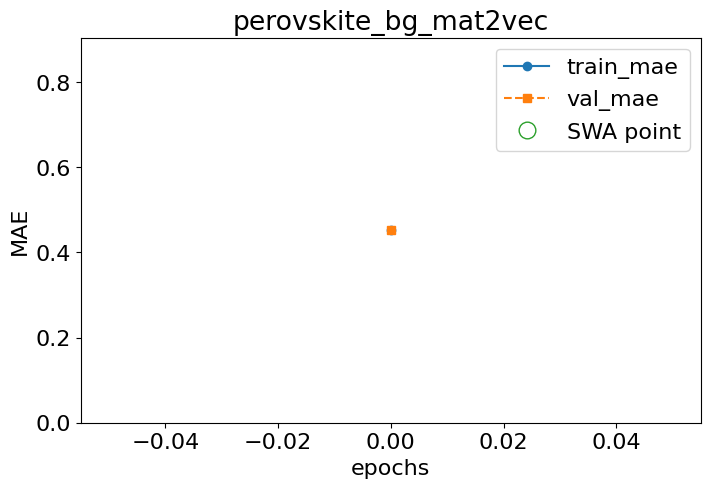

Epoch: 19/300 --- train mae: 0.241 val mae: 0.289


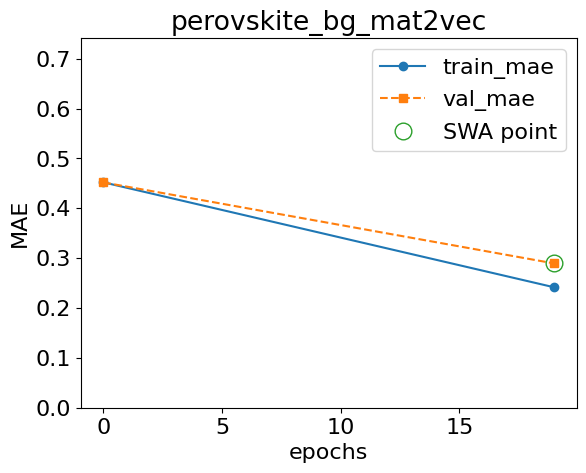

Epoch: 39/300 --- train mae: 0.158 val mae: 0.271


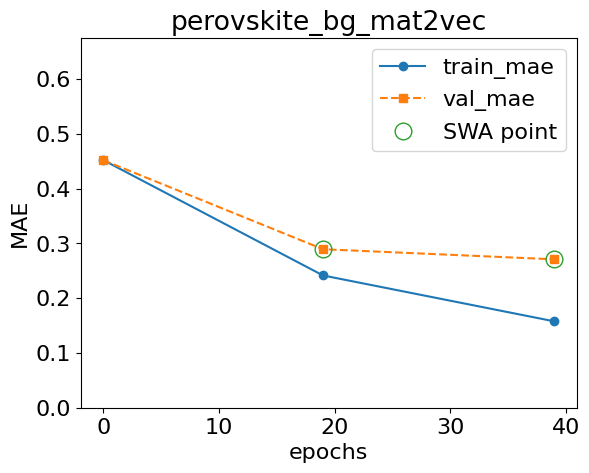

Epoch: 59/300 --- train mae: 0.105 val mae: 0.269


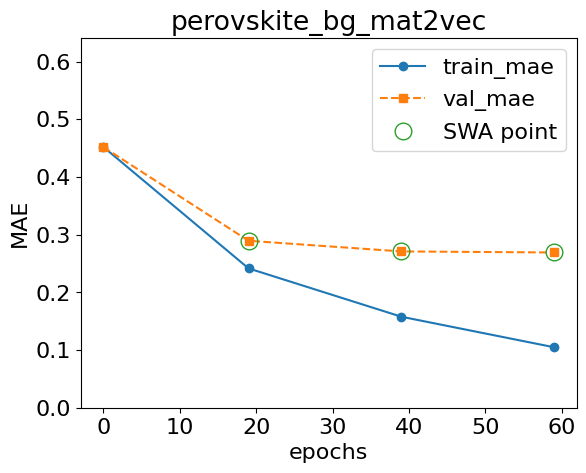

Epoch 79 failed to improve.
Discarded: 1/3 weight updates


Epoch: 79/300 --- train mae: 0.0784 val mae: 0.276


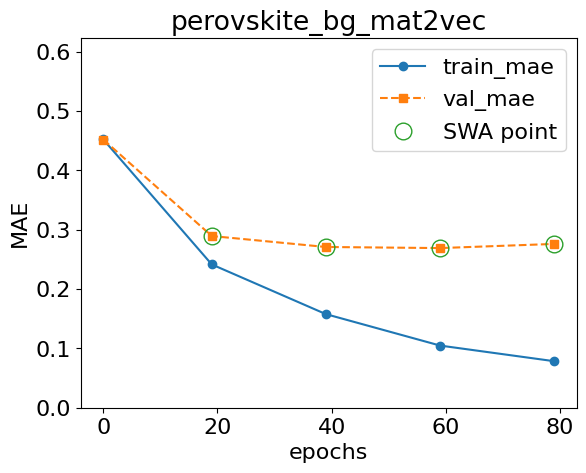

Epoch: 99/300 --- train mae: 0.0656 val mae: 0.267


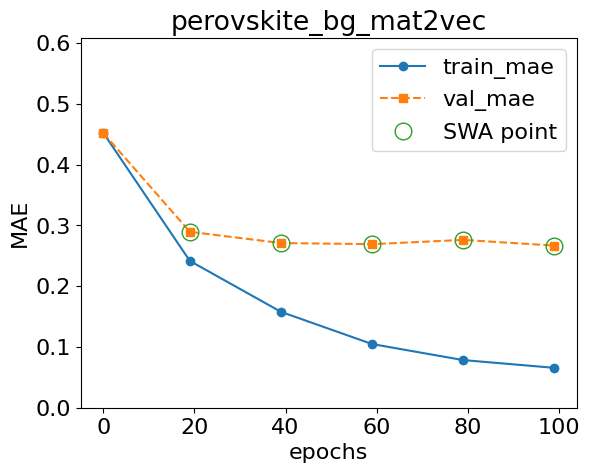

Epoch: 119/300 --- train mae: 0.0527 val mae: 0.261


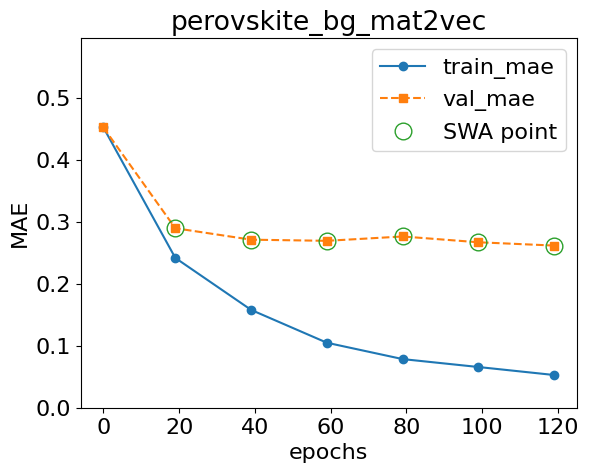

Epoch: 139/300 --- train mae: 0.0446 val mae: 0.26


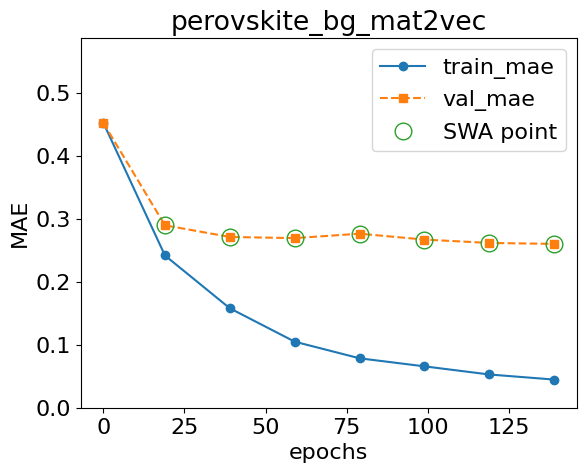

Epoch 159 failed to improve.
Discarded: 2/3 weight updates


Epoch: 159/300 --- train mae: 0.0405 val mae: 0.263


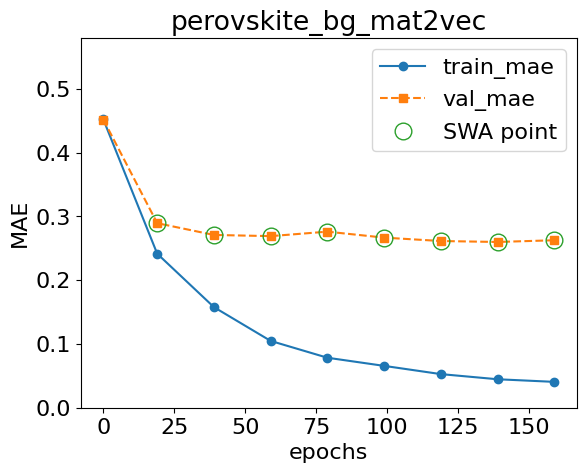

Epoch: 179/300 --- train mae: 0.0372 val mae: 0.258


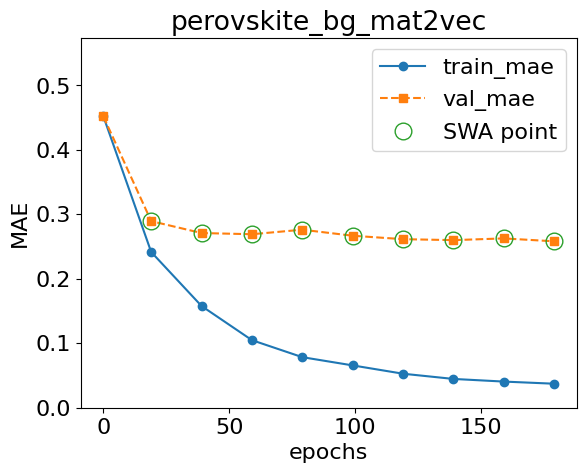

Epoch 199 failed to improve.
Discarded: 3/3 weight updates


Epoch: 199/300 --- train mae: 0.0342 val mae: 0.261


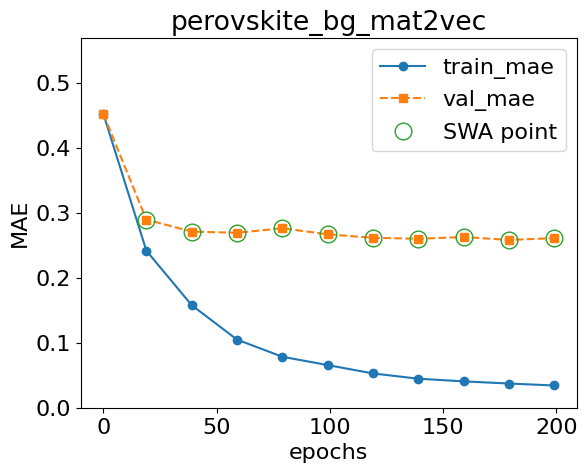

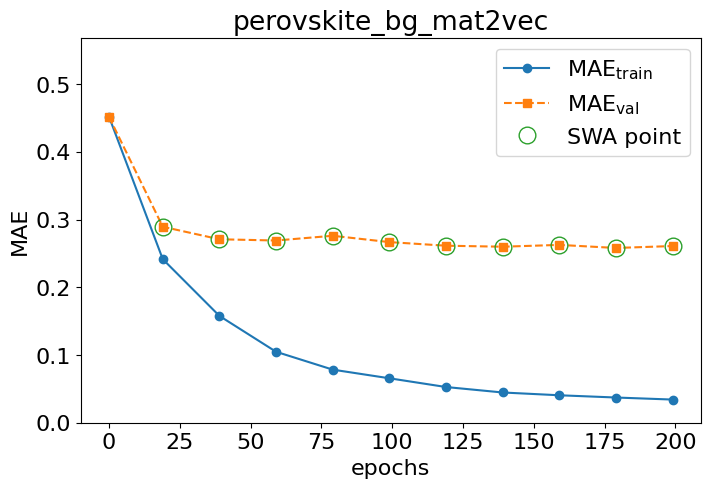

Discarded: 3/3weight updates, early-stopping now
Saving network (perovskite_bg_mat2vec) to models/trained_models/perovskite_bg_mat2vec.pth


Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 92465.22formulae/s]

skipping composition OrderedDict([('H', 115.0), ('I', 60.0), ('N', 38.0), ('Pb', 20.0), ('C', 19.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 295.0), ('I', 150.0), ('N', 98.0), ('Pb', 50.0), ('C', 49.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 102.0), ('I', 60.0), ('Pb', 20.0), ('C', 17.0), ('N', 17.0), ('X', 1.0)])
loading data with up to 9 elements in the formula


R2 score: 0.4011
MSE: 0.2590
MAE: 0.2560 eV

Encoder: onehot

Model architecture: out_dims, d_model, N, heads
3, 512, 3, 4
Running on compute device: cuda:0
Model size: 11945222 parameters



...

Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 183658.91formulae/s]

skipping composition OrderedDict([('H', 585.0), ('I', 300.0), ('N', 194.0), ('Pb', 100.0), ('C', 97.0), ('S', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 145.0), ('I', 75.0), ('N', 48.0), ('Pb', 25.0), ('C', 24.0), ('S', 1.0), ('X', 1.0)])


loading data with up to 9 elements in the formula
stepping every 120 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.453 val mae: 0.452


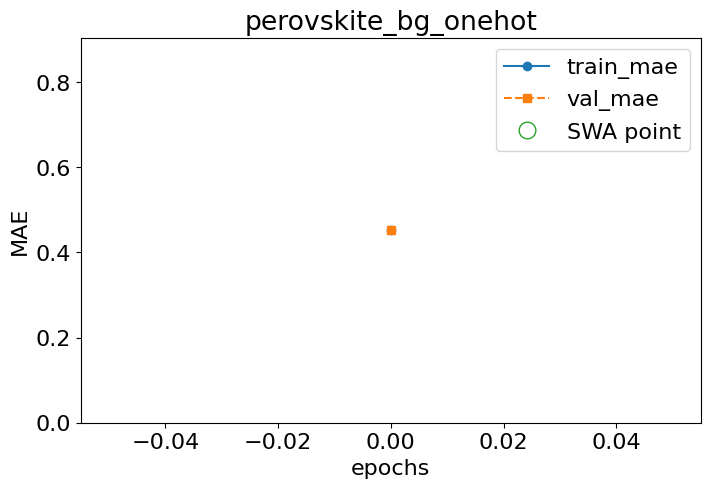

Epoch: 19/300 --- train mae: 0.275 val mae: 0.309


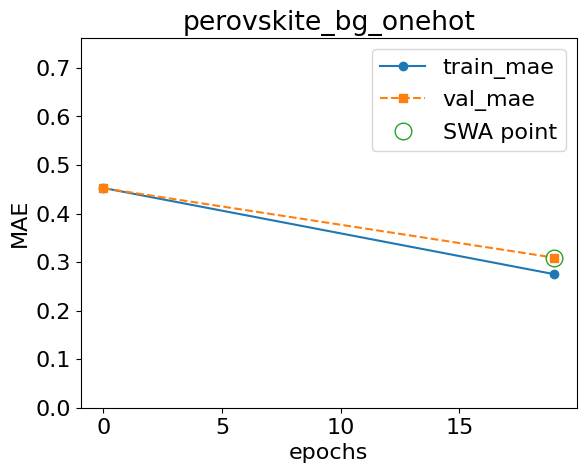

Epoch: 39/300 --- train mae: 0.192 val mae: 0.282


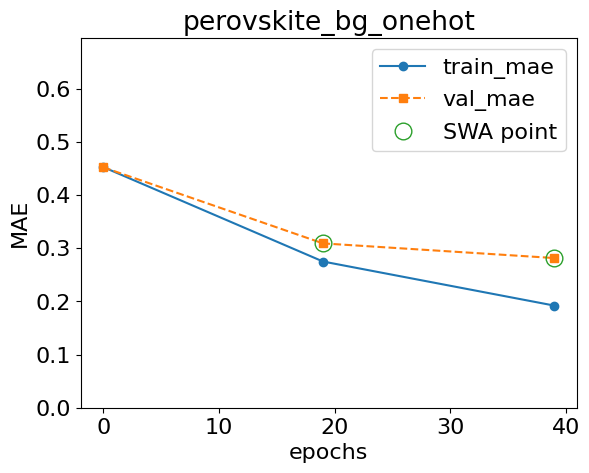

Epoch: 59/300 --- train mae: 0.132 val mae: 0.283


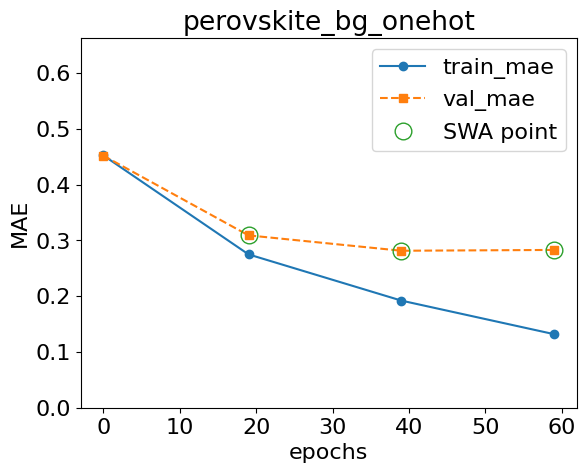

Epoch: 79/300 --- train mae: 0.0917 val mae: 0.28


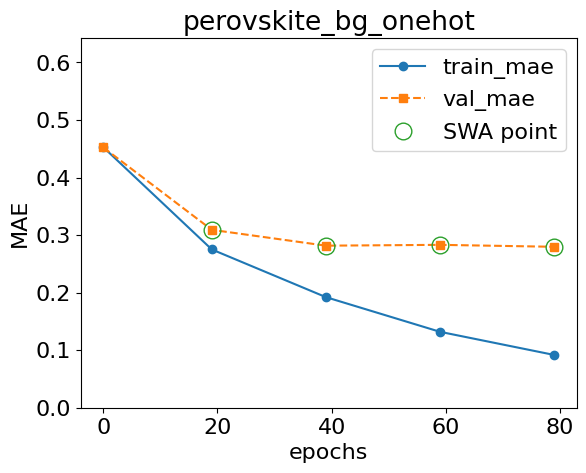

Epoch: 99/300 --- train mae: 0.0682 val mae: 0.277


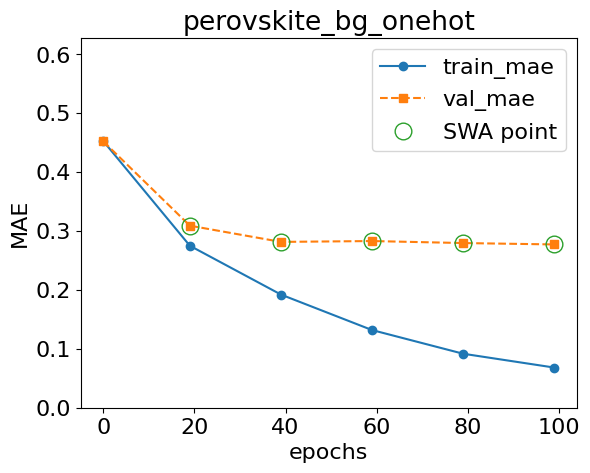

Epoch 119 failed to improve.
Discarded: 1/3 weight updates


Epoch: 119/300 --- train mae: 0.0534 val mae: 0.28


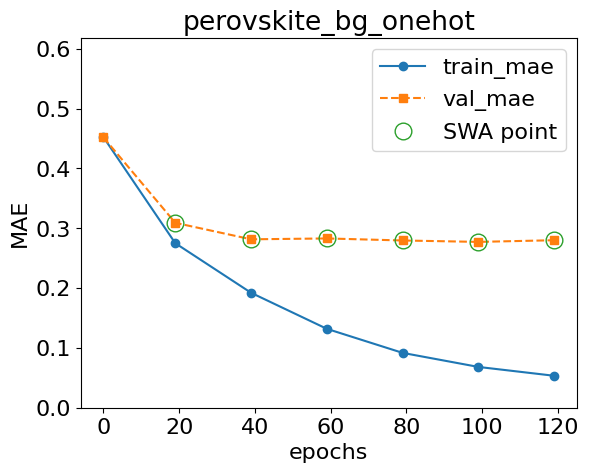

Epoch 139 failed to improve.
Discarded: 2/3 weight updates


Epoch: 139/300 --- train mae: 0.0442 val mae: 0.281


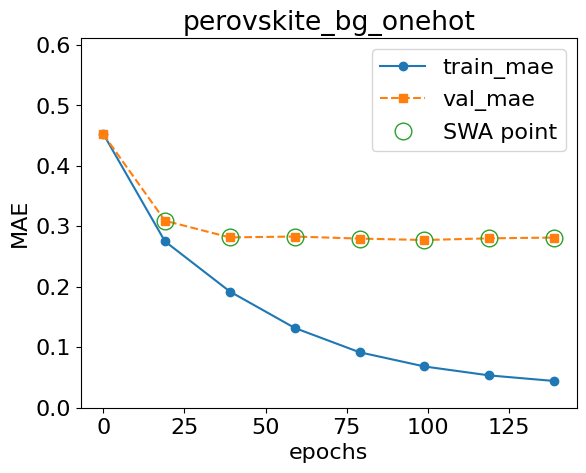

Epoch 159 failed to improve.
Discarded: 3/3 weight updates


Epoch: 159/300 --- train mae: 0.0381 val mae: 0.28


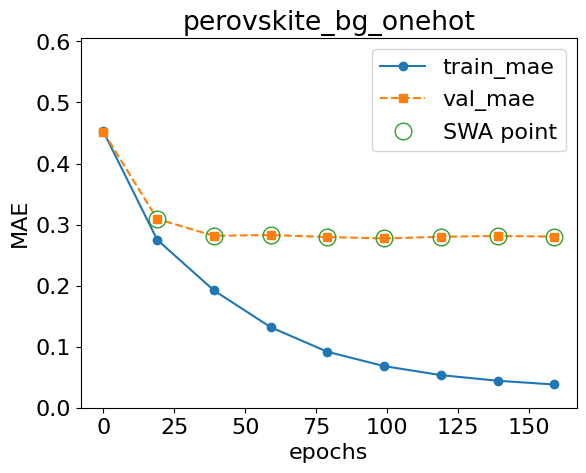

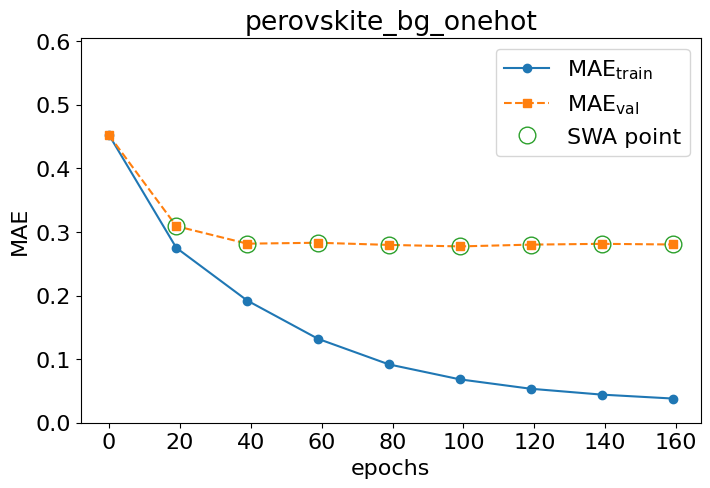

Discarded: 3/3weight updates, early-stopping now
Saving network (perovskite_bg_onehot) to models/trained_models/perovskite_bg_onehot.pth


Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 223638.71formulae/s]

skipping composition OrderedDict([('H', 115.0), ('I', 60.0), ('N', 38.0), ('Pb', 20.0), ('C', 19.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 295.0), ('I', 150.0), ('N', 98.0), ('Pb', 50.0), ('C', 49.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 102.0), ('I', 60.0), ('Pb', 20.0), ('C', 17.0), ('N', 17.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
R2 score: 0.3838
MSE: 0.2664
MAE: 0.2496 eV

Encoder: random_200

Model architecture: out_dims, d_model, N, heads
3, 512, 3, 4
Running on compute device: cuda:0
Model size: 11987206 parameters



Generating EDM:   0%|          | 0/2902 [00:00<?, ?formulae/s]

...

skipping composition OrderedDict([('I', 3.0), ('Pb', 1.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 24.0), ('I', 10.0), ('C', 6.0), ('N', 3.0), ('Pb', 3.0), ('B', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 95.0), ('N', 38.0), ('C', 19.0), ('P', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 6.0), ('I', 3.0), ('P', 2.0), ('C', 1.0), ('N', 1.0), ('Pb', 1.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
training with batchsize 256 (2**8.000)


Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 199964.85formulae/s]

skipping composition OrderedDict([('H', 585.0), ('I', 300.0), ('N', 194.0), ('Pb', 100.0), ('C', 97.0), ('S', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 145.0), ('I', 75.0), ('N', 48.0), ('Pb', 25.0), ('C', 24.0), ('S', 1.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
stepping every 120 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.461 val mae: 0.463


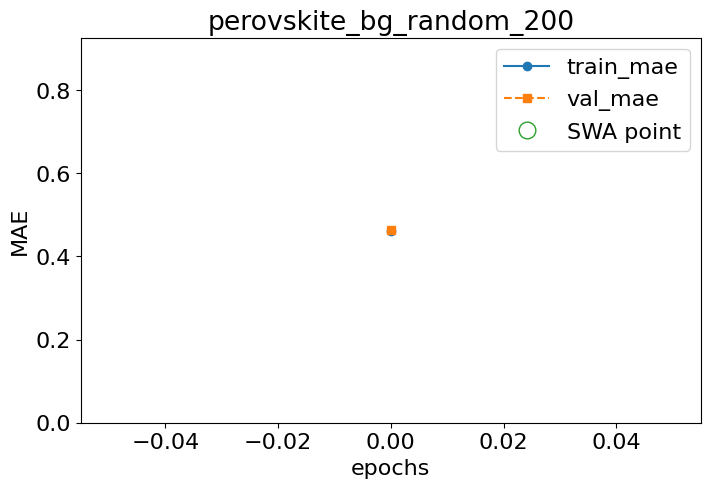

Epoch: 19/300 --- train mae: 0.301 val mae: 0.325


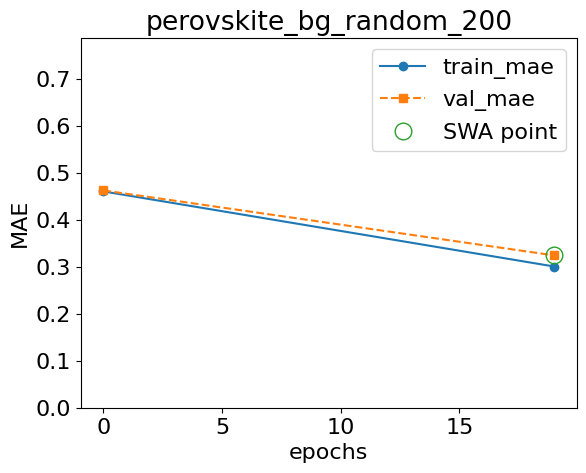

Epoch: 39/300 --- train mae: 0.212 val mae: 0.3


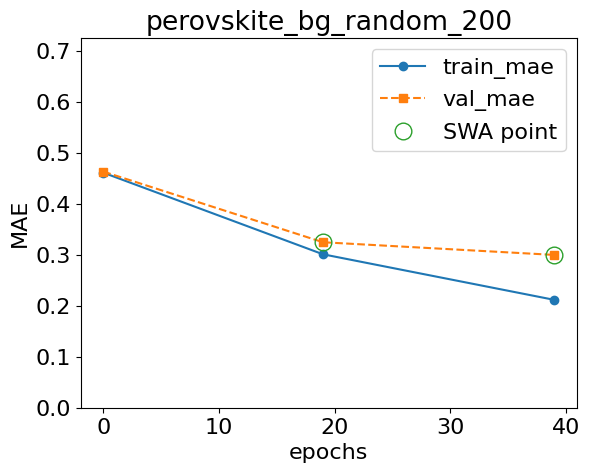

Epoch: 59/300 --- train mae: 0.154 val mae: 0.288


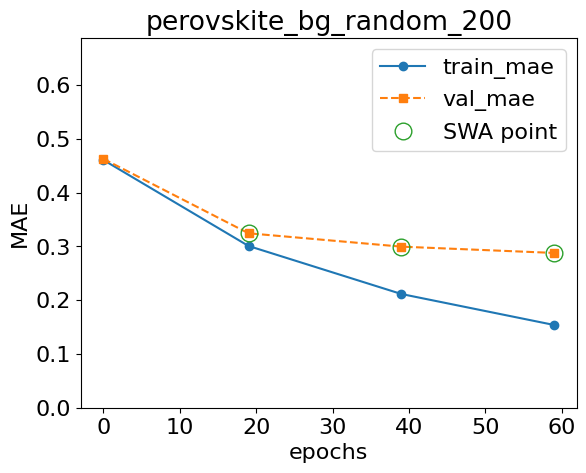

Epoch: 79/300 --- train mae: 0.104 val mae: 0.285


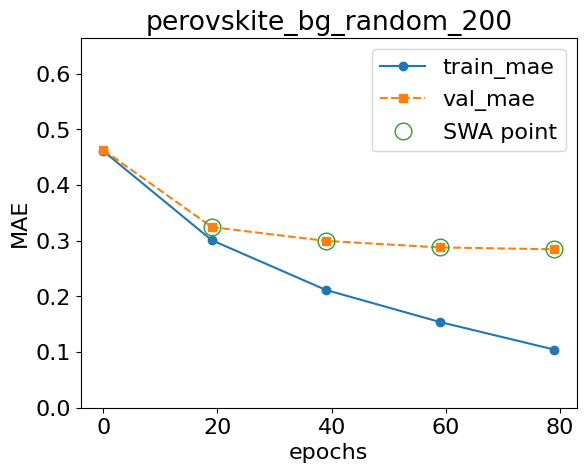

Epoch: 99/300 --- train mae: 0.076 val mae: 0.281


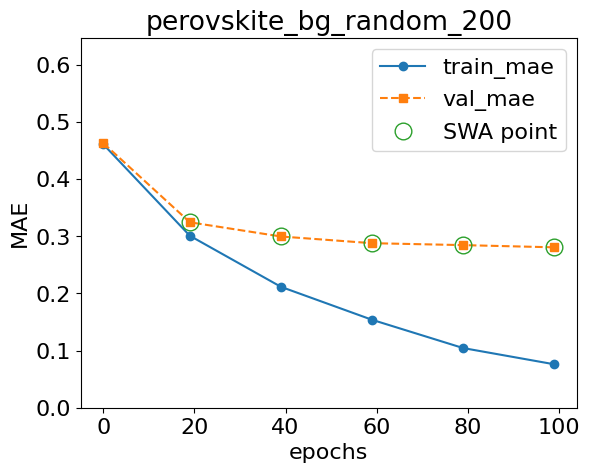

Epoch: 119/300 --- train mae: 0.0576 val mae: 0.275


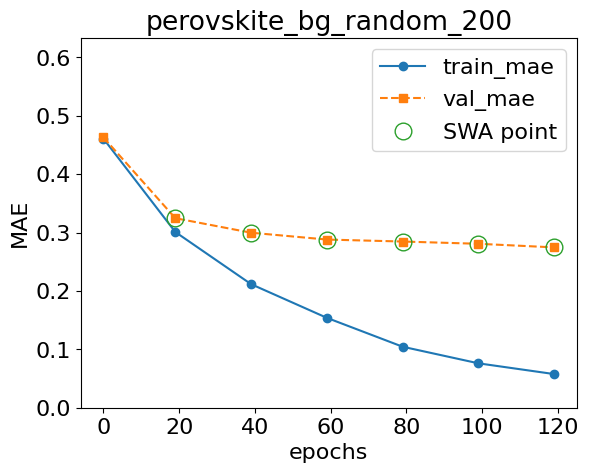

Epoch: 139/300 --- train mae: 0.0474 val mae: 0.277


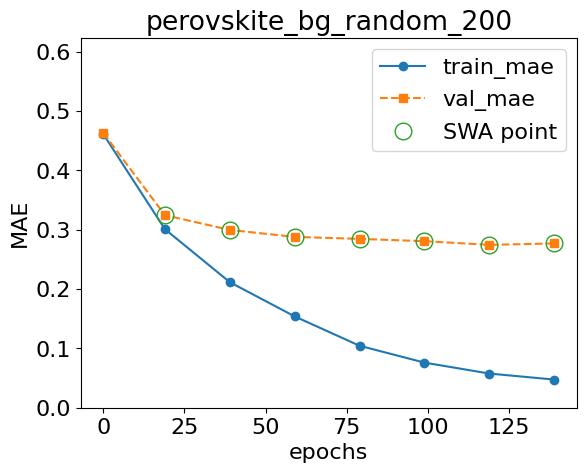

Epoch 159 failed to improve.
Discarded: 1/3 weight updates


Epoch: 159/300 --- train mae: 0.0407 val mae: 0.28


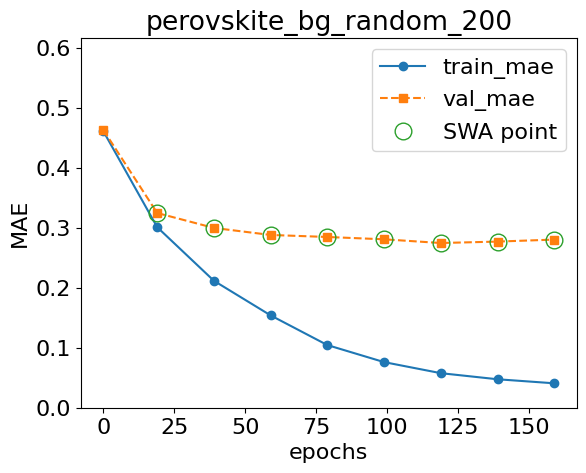

Epoch: 179/300 --- train mae: 0.0367 val mae: 0.276


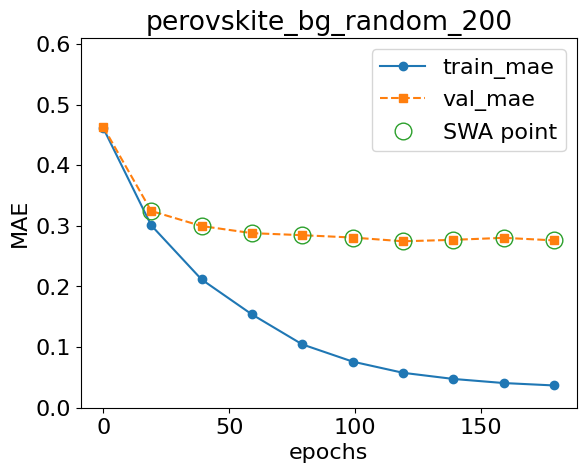

Epoch 199 failed to improve.
Discarded: 2/3 weight updates


Epoch: 199/300 --- train mae: 0.0324 val mae: 0.282


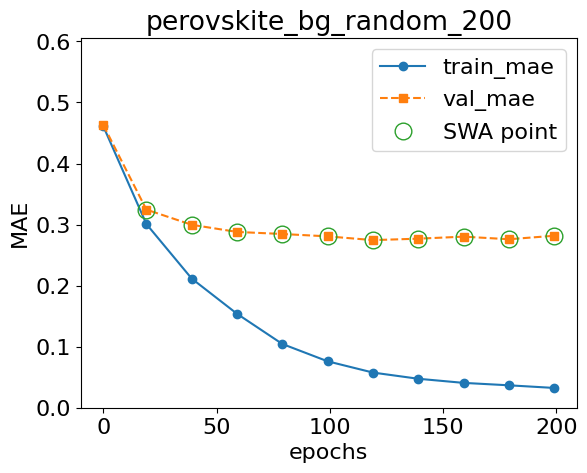

Epoch 219 failed to improve.
Discarded: 3/3 weight updates


Epoch: 219/300 --- train mae: 0.0299 val mae: 0.28


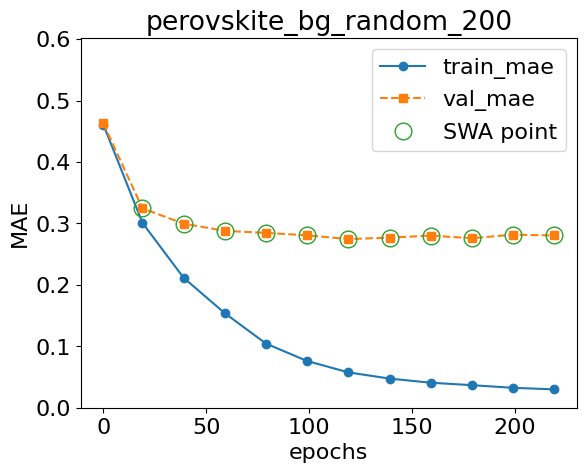

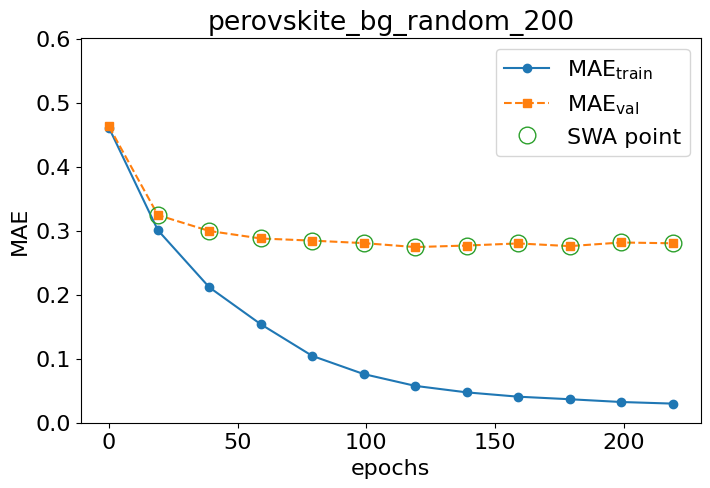

Discarded: 3/3weight updates, early-stopping now
Saving network (perovskite_bg_random_200) to models/trained_models/perovskite_bg_random_200.pth


Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 129555.17formulae/s]

skipping composition OrderedDict([('H', 115.0), ('I', 60.0), ('N', 38.0), ('Pb', 20.0), ('C', 19.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 295.0), ('I', 150.0), ('N', 98.0), ('Pb', 50.0), ('C', 49.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 102.0), ('I', 60.0), ('Pb', 20.0), ('C', 17.0), ('N', 17.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
R2 score: 0.3665
MSE: 0.2739
MAE: 0.2545 eV

Encoder: pettifor

Model architecture: out_dims, d_model, N, heads
3, 512, 3, 4
Running on compute device: cuda:0
Model size: 11934982 parameters



Generating EDM:   0%|          | 0/2902 [00:00<?, ?formulae/s]

...

skipping composition OrderedDict([('H', 5.0), ('I', 3.0), ('N', 2.0), ('C', 1.0), ('Sn', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 1054.0), ('I', 600.0), ('N', 391.0), ('C', 230.0), ('Pb', 200.0), ('Cs', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 38.0), ('I', 15.0), ('C', 9.0), ('N', 5.0), ('Pb', 5.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 344.0), ('I', 150.0), ('B', 50.0), ('Pb', 50.0), ('C', 49.0), ('N', 49.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('I', 3.0), ('Pb', 1.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 24.0), ('I', 10.0), ('C', 6.0), ('N', 3.0), ('Pb', 3.0), ('B', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 95.0), ('N', 38.0), ('C', 19.0), ('P', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 6.0), ('I', 3.0), ('P', 2.0), ('C', 1.0), ('N', 1.0), ('Pb', 1.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
training with batchsize 256 (2**8.00

Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 149914.57formulae/s]

skipping composition OrderedDict([('H', 585.0), ('I', 300.0), ('N', 194.0), ('Pb', 100.0), ('C', 97.0), ('S', 3.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 145.0), ('I', 75.0), ('N', 48.0), ('Pb', 25.0), ('C', 24.0), ('S', 1.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
stepping every 120 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.454 val mae: 0.455


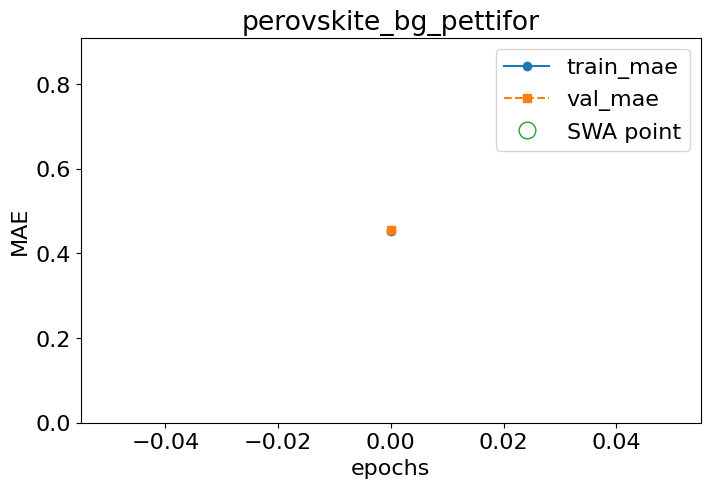

Epoch: 19/300 --- train mae: 0.276 val mae: 0.31


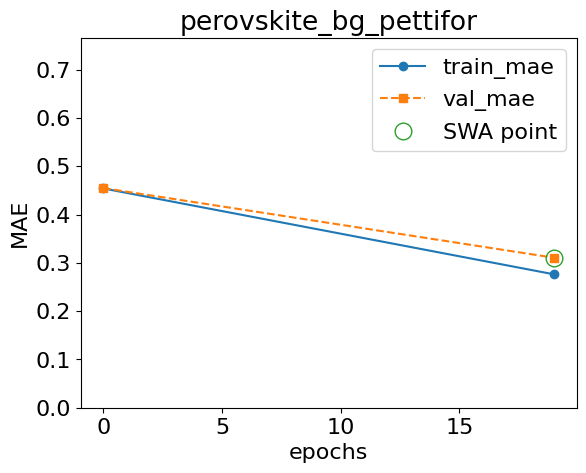

Epoch: 39/300 --- train mae: 0.198 val mae: 0.283


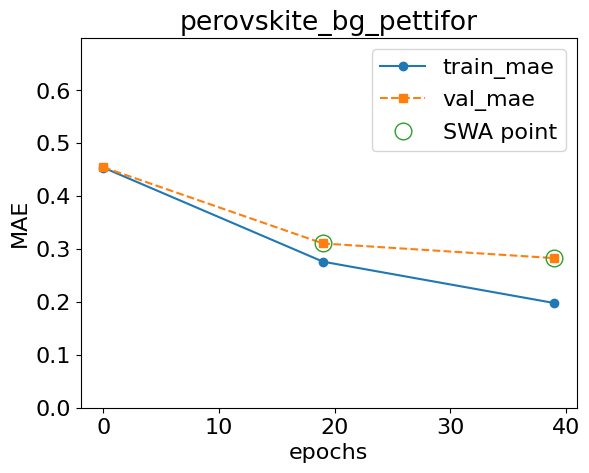

Epoch: 59/300 --- train mae: 0.143 val mae: 0.266


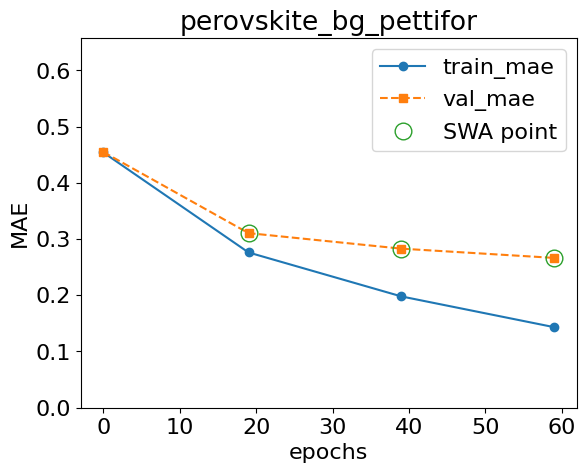

Epoch: 79/300 --- train mae: 0.104 val mae: 0.265


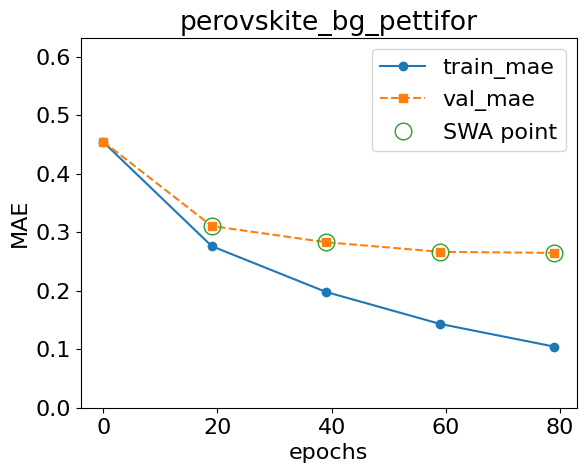

Epoch: 99/300 --- train mae: 0.0785 val mae: 0.262


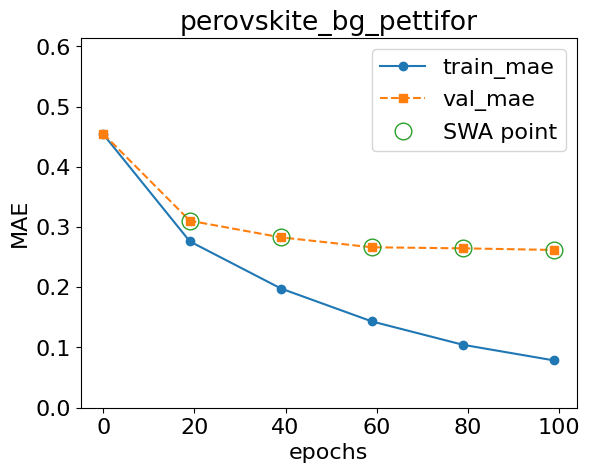

Epoch 119 failed to improve.
Discarded: 1/3 weight updates


Epoch: 119/300 --- train mae: 0.0614 val mae: 0.267


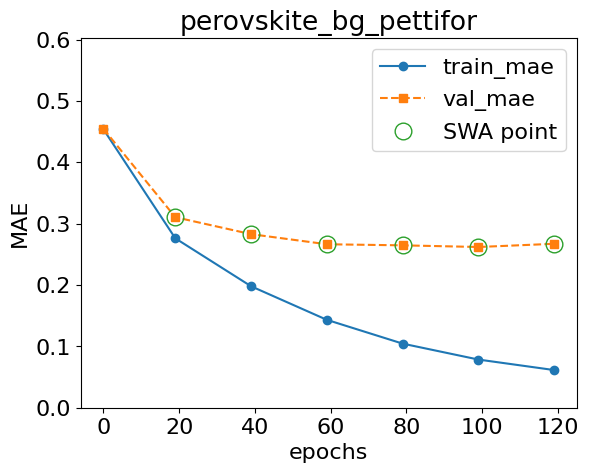

Epoch: 139/300 --- train mae: 0.0528 val mae: 0.263


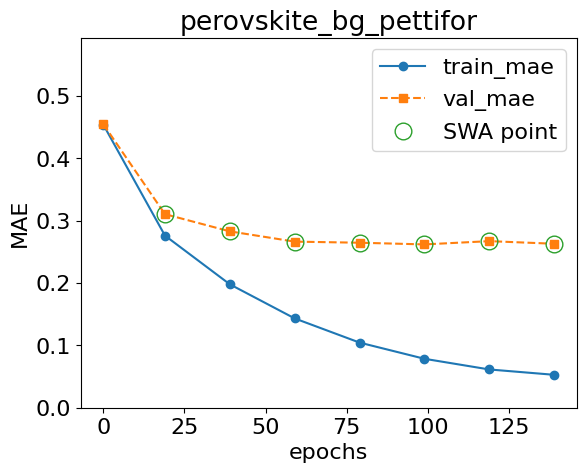

Epoch: 159/300 --- train mae: 0.042 val mae: 0.26


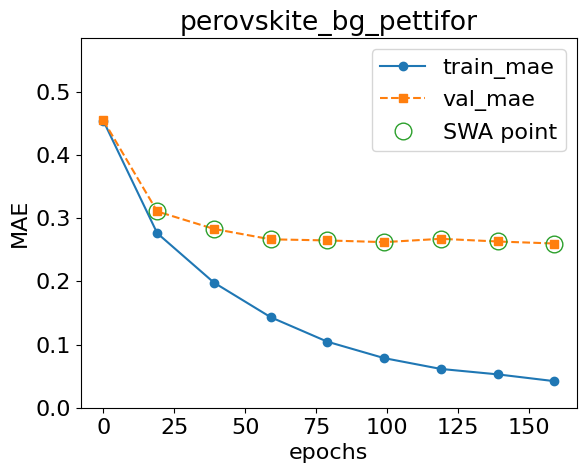

Epoch: 179/300 --- train mae: 0.0364 val mae: 0.257


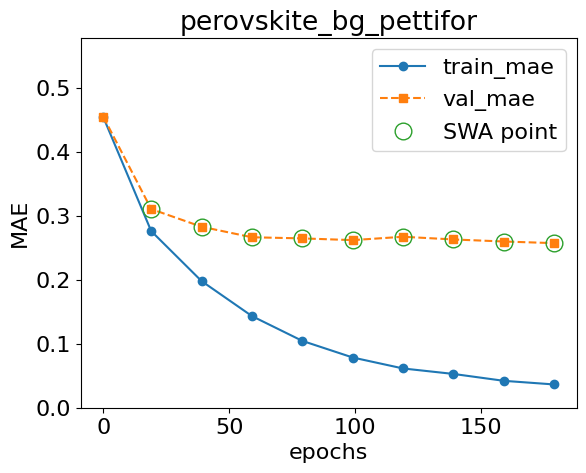

Epoch: 199/300 --- train mae: 0.0321 val mae: 0.258


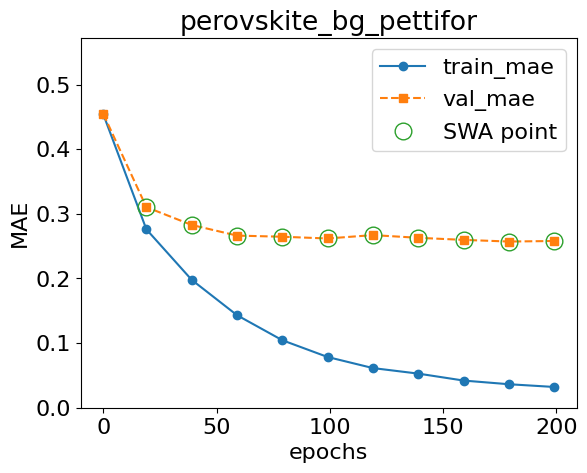

Epoch 219 failed to improve.
Discarded: 2/3 weight updates


Epoch: 219/300 --- train mae: 0.0303 val mae: 0.264


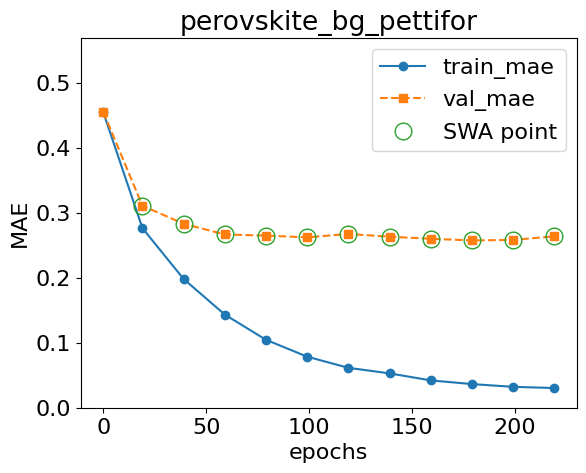

Epoch: 239/300 --- train mae: 0.0278 val mae: 0.259


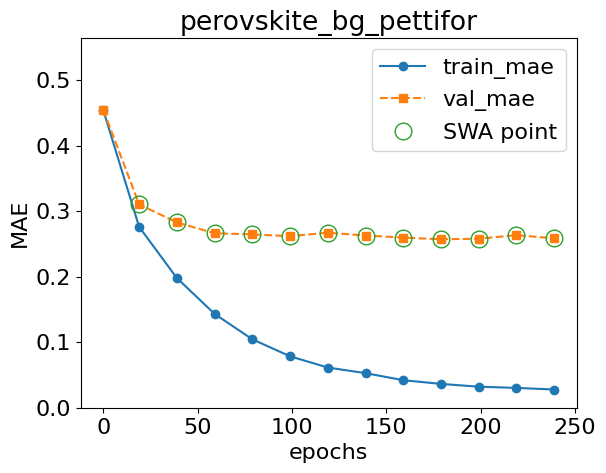

Epoch 259 failed to improve.
Discarded: 3/3 weight updates


Epoch: 259/300 --- train mae: 0.0267 val mae: 0.264


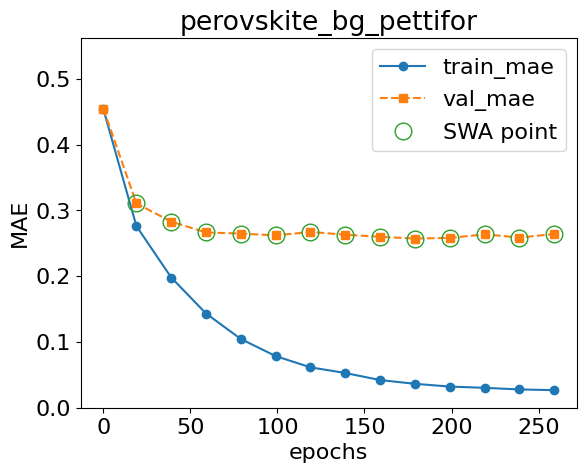

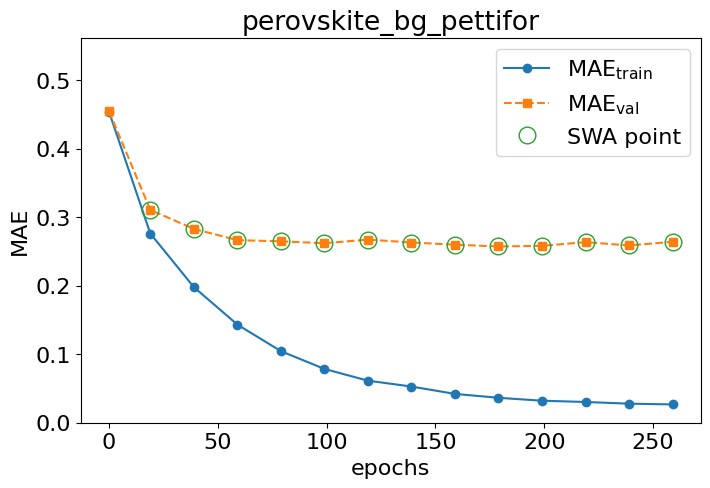

Discarded: 3/3weight updates, early-stopping now
Saving network (perovskite_bg_pettifor) to models/trained_models/perovskite_bg_pettifor.pth


Generating EDM:   0%|          | 0/363 [00:00<?, ?formulae/s]

Generating EDM: 100%|██████████| 363/363 [00:00<00:00, 210033.43formulae/s]

skipping composition OrderedDict([('H', 115.0), ('I', 60.0), ('N', 38.0), ('Pb', 20.0), ('C', 19.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 295.0), ('I', 150.0), ('N', 98.0), ('Pb', 50.0), ('C', 49.0), ('S', 1.0), ('X', 1.0)])
skipping composition OrderedDict([('H', 102.0), ('I', 60.0), ('Pb', 20.0), ('C', 17.0), ('N', 17.0), ('X', 1.0)])
loading data with up to 9 elements in the formula
R2 score: 0.3815
MSE: 0.2674
MAE: 0.2522 eV


,encoder,R²,MAE (eV),RMSE (eV)
2,onehot,0.384,0.250,0.516
4,pettifor,0.382,0.252,0.517
3,random_200,0.366,0.255,0.523
1,mat2vec,0.401,0.256,0.509
0,magpie,0.353,0.270,0.529


In [3]:
ENCODERS = ['magpie', 'mat2vec', 'onehot', 'random_200', 'pettifor']

# ENCODERS = [ 'onehot', 'pettifor']

encoder_results = []

for encoder in ENCODERS:
    print(f'\n{"="*50}')
    print(f'Encoder: {encoder}')
    print(f'{"="*50}')

    model_name = f'perovskite_bg_{encoder}'

    model = CrabNet(
        mat_prop='bandgap',
        model_name=model_name,
        elem_prop=encoder,
        learningcurve=True,
    )
    model.fit(train_base.copy(), val_base.copy())

    m = test_r2_score(
        test_base, feature_names=None,
        crabnet_bandgap=model, plot=False,
    )

    encoder_results.append({
        'encoder': encoder,
        'R²': m['r2'],
        'MAE (eV)': m['mae'],
        'RMSE (eV)': np.sqrt(m['mse']),
    })

enc_table = pd.DataFrame(encoder_results).sort_values('MAE (eV)')
enc_table.style.format({'R²': '{:.3f}', 'MAE (eV)': '{:.3f}', 'RMSE (eV)': '{:.3f}'})

## Comparison Bar Chart

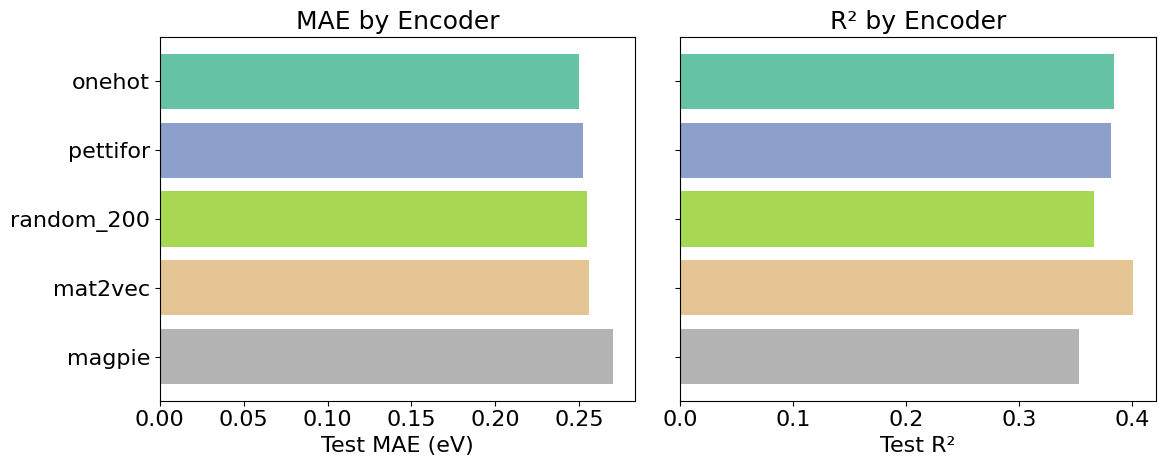

Saved to /home/dagar/TF-ChPVK-PV/reports/figures/encoder_comparison.png


In [4]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.set_context('talk')

colors = plt.cm.Set2(np.linspace(0, 1, len(enc_table)))

# MAE
axes[0].barh(enc_table['encoder'], enc_table['MAE (eV)'], color=colors)
axes[0].set_xlabel('Test MAE (eV)')
axes[0].set_title('MAE by Encoder')
axes[0].invert_yaxis()

# R²
axes[1].barh(enc_table['encoder'], enc_table['R²'], color=colors)
axes[1].set_xlabel('Test R²')
axes[1].set_title('R² by Encoder')

plt.tight_layout()
#fig.savefig(FIGURES_DIR / 'encoder_comparison.pdf')
fig.savefig(FIGURES_DIR / 'encoder_comparison.png')
plt.show()
print(f'Saved to {FIGURES_DIR / "encoder_comparison.png"}')

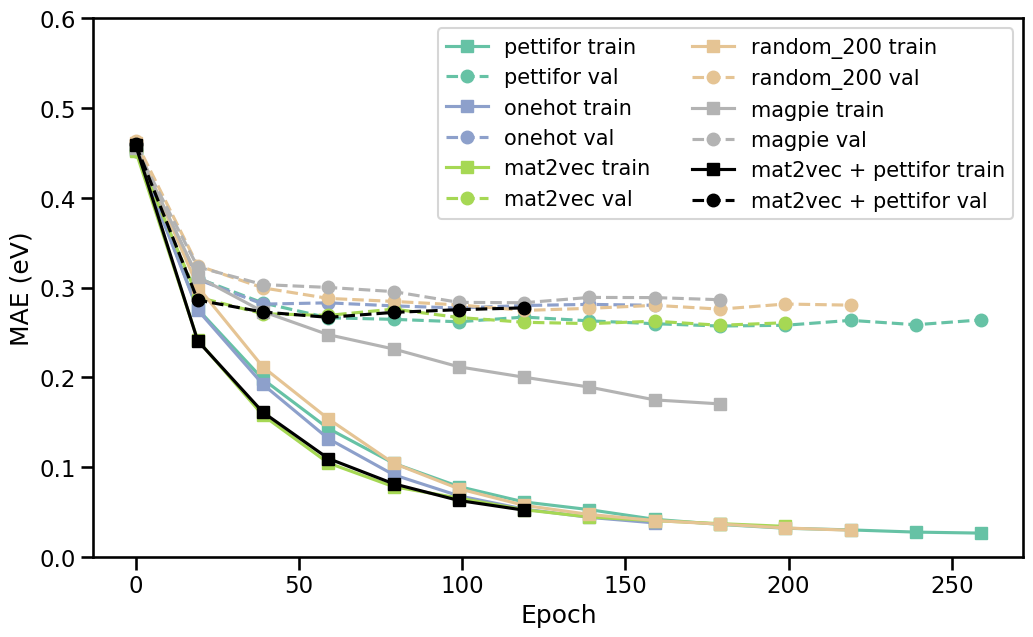

In [5]:
from chalcogenide_perovskite_screening.config import FIGURES_NOTEBOOK_DIR, FIGURES_DIR
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_context('talk')

#training curve
ENCODERS = ['pettifor', 'onehot', 'mat2vec', 'random_200', 'magpie', 'prediction']
colors = plt.cm.Set2(np.linspace(0, 1, 5)).tolist()  + ['black']

plt.figure(figsize=(12, 7))

for encoder, color in zip(ENCODERS, colors):
    model_csv = f'perovskite_bg_{encoder}_lc.csv'
    model_csv_path =  FIGURES_NOTEBOOK_DIR / model_csv

    df = pd.read_csv(model_csv_path)

    if encoder == 'prediction':
        encoder_label = 'mat2vec + pettifor'
    else:
        encoder_label = encoder

    plt.plot(df['epoch'], df['train loss'], label=f'{encoder_label} train', color=color, marker='s')
    plt.plot(df['epoch'], df['val loss'], label=f'{encoder_label} val', linestyle='--', color=color,  marker='o')
    plt.scatter(df['epoch'], df['val loss'], color=color, s=20, marker='o')


plt.xlabel('Epoch')
plt.ylabel('MAE (eV)')
plt.ylim([0, 0.6])
plt.legend(loc='upper right', fontsize=15, ncols=2)
plt.savefig(FIGURES_DIR / 'training_curves_all_encoders.png', dpi=300, bbox_inches='tight')

plt.show()